## Regularization Techniques Visualized (CPU Friendly)
In the following code nodes below, I will be demonstarting the effects of the following deep learning regularization techniques on a simple model.
- L1 Regularization (absolute weight)
- L2 Regularization (squared weight)
- Elastic Net (simplified L1 & L2)
- Dropout
- Batch Normalization

In [23]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

X, y = make_moons(n_samples=500, noise=0.25)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)

X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.long)

In [24]:
class SimpleNet(nn.Module):
    def __init__(self, dropout=False, batchnorm=False):
        super().__init__()
        
        self.fc1 = nn.Linear(2, 32)
        self.fc2 = nn.Linear(32, 32)
        self.fc3 = nn.Linear(32, 2)

        self.dropout = nn.Dropout(0.5) if dropout else None
        self.bn1 = nn.BatchNorm1d(32) if batchnorm else None

    def forward(self, x):
        x = self.fc1(x)
        if self.bn1:
            x = self.bn1(x)
        x = F.relu(x)
        if self.dropout:
            x = self.dropout(x)
        x = F.relu(self.fc2(x))
        return self.fc3(x)

In [25]:
def train_model(model, l1=0.0, l2=0.0, epochs=200):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=l2)
    criterion = nn.CrossEntropyLoss()

    losses = []
    for epoch in range(epochs):

        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)

        # L1 penalty
        if l1 > 0:
            l1_penalty = sum(p.abs().sum() for p in model.parameters())
            loss += l1 * l1_penalty

        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    return losses

In [26]:
def plot_decision_boundary(model, ax, title):
    x_min, x_max = X_train[:,0].min()-1, X_train[:,0].max()+1
    y_min, y_max = X_train[:,1].min()-1, X_train[:,1].max()+1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    with torch.no_grad():
        preds = model(grid)
        preds = torch.argmax(preds, dim=1).numpy()

    preds = preds.reshape(xx.shape)
    ax.contourf(xx, yy, preds, alpha=0.3)
    ax.scatter(X_train[:,0], X_train[:,1], c=y_train, edgecolor='k')
    ax.set_title(title)

In [27]:
models = {}
models["Baseline"] = SimpleNet()
train_model(models["Baseline"])

models["L2"] = SimpleNet()
train_model(models["L2"], l2=0.01)

models["L1"] = SimpleNet()
train_model(models["L1"], l1=0.001)

models["ElasticNet"] = SimpleNet()
train_model(models["ElasticNet"], l1=0.001, l2=0.01)

models["Dropout"] = SimpleNet(dropout=True)
train_model(models["Dropout"])

models["BatchNorm"] = SimpleNet(batchnorm=True)
train_model(models["BatchNorm"])

[0.7492843270301819,
 0.6287416219711304,
 0.5436376929283142,
 0.4795917570590973,
 0.43256714940071106,
 0.3993077874183655,
 0.37704992294311523,
 0.36094847321510315,
 0.3478824198246002,
 0.33683833479881287,
 0.32859307527542114,
 0.323658287525177,
 0.3208291828632355,
 0.31821322441101074,
 0.3146233558654785,
 0.3096310794353485,
 0.3035202622413635,
 0.2972622513771057,
 0.2916330397129059,
 0.2868666350841522,
 0.28290891647338867,
 0.27958211302757263,
 0.2764880955219269,
 0.27351635694503784,
 0.2704780399799347,
 0.267123281955719,
 0.2632988691329956,
 0.25888922810554504,
 0.2541583478450775,
 0.2491595298051834,
 0.24412338435649872,
 0.23926474153995514,
 0.23481278121471405,
 0.2306695580482483,
 0.22657360136508942,
 0.22220183908939362,
 0.21739202737808228,
 0.21241071820259094,
 0.2074897736310959,
 0.20270179212093353,
 0.1981019824743271,
 0.19371719658374786,
 0.18953032791614532,
 0.1856161504983902,
 0.18187958002090454,
 0.1781347393989563,
 0.174280226230

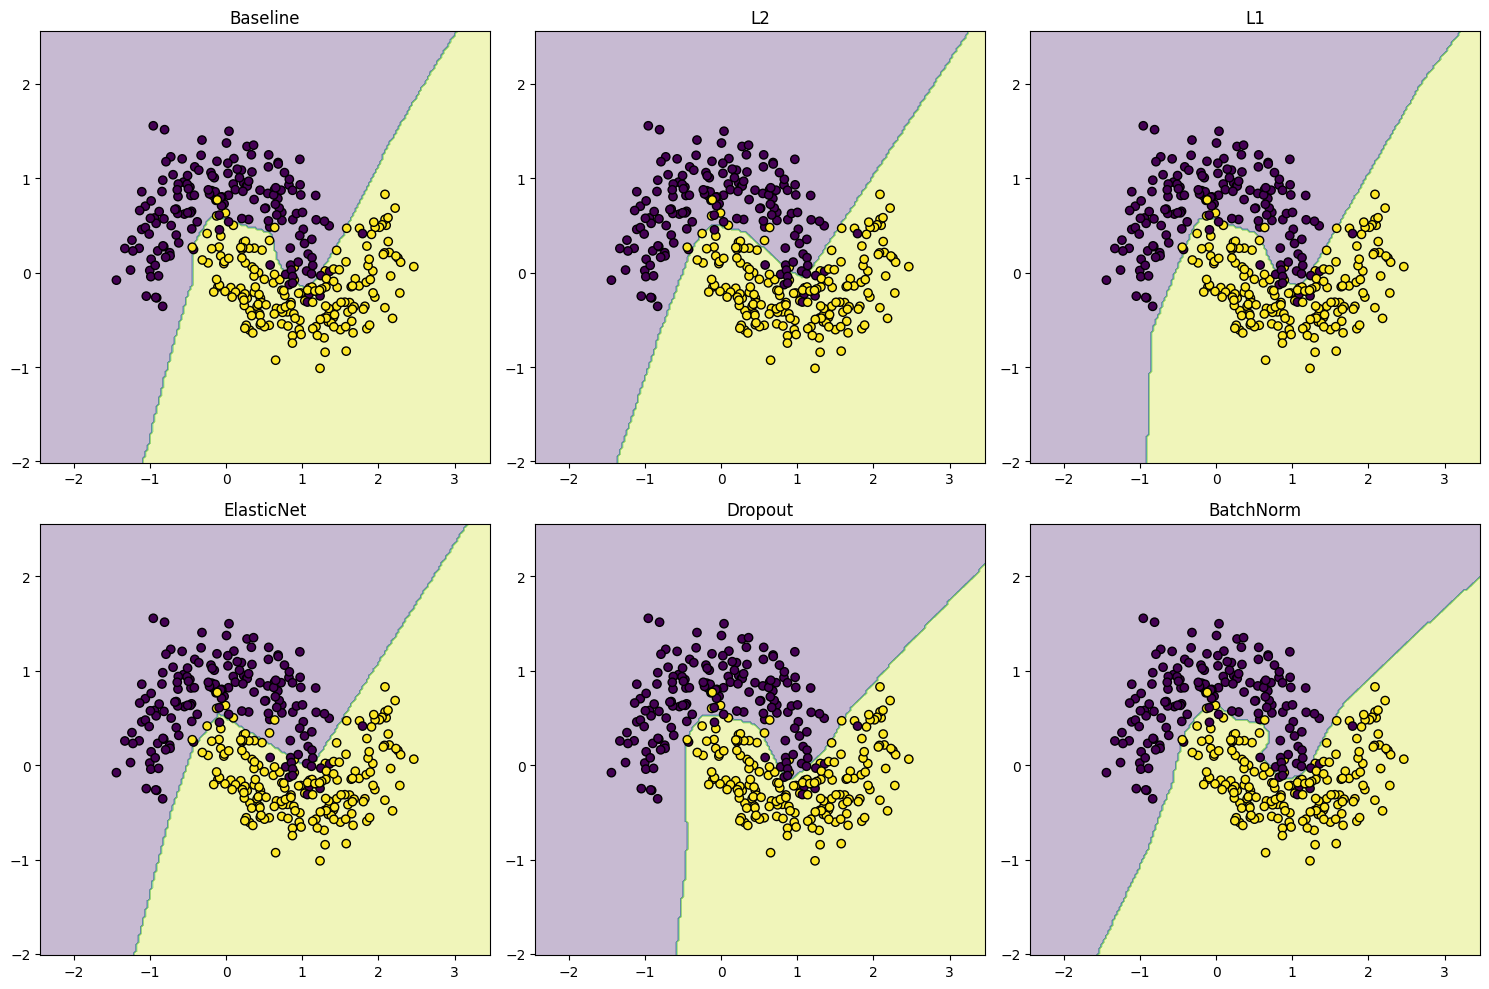

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(15,10))
axes = axes.flatten()

for ax, (name, model) in zip(axes, models.items()):
    model.eval()
    plot_decision_boundary(model, ax, name)

plt.tight_layout()
plt.show()

### Observations
So, what are we looking for in these subplots?

The goal of regularization is to prevent overfitting and model reliance on noise. 

Our **baseline** above is a good starting point for this. As we can see, the model bends and contorts itself the most to try and encapsulate every single point. This is **BAD**. Overfitting decreases model accuracy over time and makes them less likely to perform well on different datasets. Because of this, we need to implement regularization.

**L2** is noticeable from baseline as it penalizes large weights. This results in a smoother boundary and less significant bends as compared to the baseline. L2 is able to move in a more direct line and not adjust its boundary frequently which allows for a more generalized fit (no overfitting! YAY!).

**L1** is similar in idea to L2, but instead of penalizing large weights, it encourages sparse weights. In its formula, it adds the sum of the absolute values of the weights to the loss function which encourages the model to keep weights small or even zero. This contrasts with L2 which adds the sum of squared weights to the loss function. So, L1 can reach weights of zero, but L2 cannot.

This contrast is eveident between L1 and L2 visuals as we can see that L1 results in a more direct and less smooth boundary as compared to L2.

**Elastic Net** combines the useful features of both L1 and L2 to generate a smoother, yet more direct, boundary than L1 and L2. 

**Dropout** is one of the more notable regularization techniques as we can see in its definitive boundary. Dropout is considered robust as it is not easily persuaded by noise and it produces an evidently smooth curve. In this visual, it is clear from the lack of change in the boundary that the model is not heavily persuaded and takes a more general fit.

**Batch Normalization** can be considered a regulzarization technique, however its effects are less visual and more comparable to the baseline than other techniques previously explored. Batch normalization mostly affects a models training, **not its complexity**. In other words, Batch Normalization does not directly penalize weights or neurons as seen in L1, L2, Elastic Net, and Dropout. Regardless, Batch Normalization is powerful technique for models because of its ability to introduce faster training and more stable gradients. 